<a href="https://colab.research.google.com/github/khaoulammn/Active_learning/blob/main/Train_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Détection d'Antennes BTS
**Modèles testés :** YOLOv8s · YOLOv8m · YOLOv9s · YOLO11s · YOLO11m

---

## Étape 1  Installation & Imports

In [ ]:
!pip install ultralytics --quiet

import os
import json
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO

print("Imports OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


##  Étape 2 — Montage Drive & Vérification Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- Chemins ---
DRIVE_PROJECT = "/content/drive/MyDrive/YOLO_project"
ZIP_PATH      = f"{DRIVE_PROJECT}/dataset_split.zip"
DATASET_PATH  = "/content/dataset_split"
RESULTS_PATH  = f"{DRIVE_PROJECT}/results"   # Sauvegarde des résultats sur Drive
os.makedirs(RESULTS_PATH, exist_ok=True)

# --- Extraction ---
if not os.path.exists(DATASET_PATH):
    print(" Extraction du dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print("Dataset extrait")
else:
    print("Dataset déjà présent")

# --- Vérification ---
for split in ['train', 'val', 'test']:
    n = len(list(Path(f"{DATASET_PATH}/images/{split}").glob("*.*")))
    print(f"  {split:>5} : {n} images")

Mounted at /content/drive
 Extraction du dataset...
Dataset extrait
  train : 1067 images
    val : 153 images
   test : 306 images


##  Étape 3 — Configuration YAML

In [ ]:
%%writefile dataset.yaml
path: /content/dataset_split

train: images/train
val:   images/val
test:  images/test

nc: 1
names:
  0: antenne

Writing dataset.yaml


##  Étape 4 — Hyperparamètres communs

In [ ]:
# ================================================================
#  CONFIGURATION COMMUNE À TOUS LES MODÈLES
# ================================================================

COMMON_PARAMS = dict(
    data       = "dataset.yaml",
    epochs     = 100,
    imgsz      = 768,
    batch      = 8,
    patience   = 20,
    workers    = 2,
    device     = 0,
    exist_ok   = True,
    verbose    = False,

    # --- Augmentations optimisées imagerie satellite ---
    mosaic     = 1.0,
    mixup      = 0.2,
    degrees    = 45.0,
    fliplr     = 0.5,
    flipud     = 0.5,
    scale      = 0.5,
    translate  = 0.1,
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    perspective= 0.0,
    shear      = 0.0,
)

# ================================================================
#  MODÈLES À TESTER
# ================================================================
MODELS_TO_TEST = [
    "yolov8s.pt",    # Baseline
    "yolov8m.pt",    #  Medium v8
    "yolov9s.pt",
    "yolov9m.pt",
    "yolo11s.pt",
    "yolo11m.pt",    # Medium dernière gen
]

print(" Configuration prête")
print(f"   Modèles à tester : {MODELS_TO_TEST}")

 Configuration prête
   Modèles à tester : ['yolov8s.pt', 'yolov8m.pt', 'yolov9s.pt', 'yolov9m.pt', 'yolo11s.pt', 'yolo11m.pt']


## Étape 5 — Entraînement & Évaluation de tous les modèles

In [ ]:
# ================================================================
#  BOUCLE D'ENTRAÎNEMENT PRINCIPALE
#  - Entraîne chaque modèle
#  - Évalue sur val + test
#  - Sauvegarde les métriques en JSON sur Drive (protection anti-crash)
# ================================================================

all_results = {}
METRICS_FILE = f"{RESULTS_PATH}/all_metrics.json"

# Reprendre depuis la sauvegarde si elle existe (utile si session Colab expires)
if os.path.exists(METRICS_FILE):
    with open(METRICS_FILE) as f:
        all_results = json.load(f)
    print(f" Résultats précédents chargés : {list(all_results.keys())}")


def extract_metrics(metrics_obj):
    """Extrait proprement les métriques d'un objet Results Ultralytics."""
    return {
        "precision" : float(metrics_obj.box.mp),
        "recall"    : float(metrics_obj.box.mr),
        "mAP50"     : float(metrics_obj.box.map50),
        "mAP50_95"  : float(metrics_obj.box.map),
    }


for model_name in MODELS_TO_TEST:
    label = model_name.replace(".pt", "")  # ex: "yolov8s"

    # Skip si déjà entraîné
    if label in all_results:
        print(f"  {label} déjà traité, skip.")
        continue

    print(f"\n{'='*60}")
    print(f"    Entraînement : {label}")
    print(f"{'='*60}")

    model = YOLO(model_name)

    t_start = time.time()
    train_results = model.train(
        **COMMON_PARAMS,
        project = "/content/runs",
        name    = label,           #  Chaque run a son propre dossier
    )
    train_time = (time.time() - t_start) / 60

    print(f"\n Évaluation {label} sur VAL...")
    val_metrics  = model.val(data="dataset.yaml", split="val",  verbose=False)

    print(f" Évaluation {label} sur TEST...")
    test_metrics = model.val(data="dataset.yaml", split="test", verbose=False)

    # Stocker les résultats
    all_results[label] = {
        "val" : extract_metrics(val_metrics),
        "test": extract_metrics(test_metrics),
        "train_time_min": round(train_time, 1),
    }

    # Sauvegarde immédiate sur Drive après chaque modèle
    with open(METRICS_FILE, "w") as f:
        json.dump(all_results, f, indent=2)

    # Copier les poids du meilleur modèle sur Drive
    best_weights = f"/content/runs/{label}/weights/best.pt"
    if os.path.exists(best_weights):
        !cp {best_weights} {RESULTS_PATH}/{label}_best.pt

    print(f"   {label} terminé en {train_time:.1f} min")
    print(f"     VAL  → mAP50: {all_results[label]['val']['mAP50']:.4f}  "
          f"| mAP50-95: {all_results[label]['val']['mAP50_95']:.4f}  "
          f"| Recall: {all_results[label]['val']['recall']:.4f}")
    print(f"     TEST → mAP50: {all_results[label]['test']['mAP50']:.4f}  "
          f"| mAP50-95: {all_results[label]['test']['mAP50_95']:.4f}  "
          f"| Recall: {all_results[label]['test']['recall']:.4f}")


print(f"\nTous les modèles entraînés !")

 Résultats précédents chargés : ['yolov8s', 'yolov8m', 'yolov9s', 'yolo11s', 'yolo11m']
  yolov8s déjà traité, skip.
  yolov8m déjà traité, skip.
  yolov9s déjà traité, skip.

    Entraînement : yolov9m
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=45.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2,

##  Étape 6 — Tableau récapitulatif des métriques

In [ ]:
# ================================================================
#  TABLEAU RÉCAPITULATIF
# ================================================================

rows = []
for label, data in all_results.items():
    rows.append({
        "Modèle"        : label,
        "P (test)"      : round(data["test"]["precision"],  4),
        "R (test)"      : round(data["test"]["recall"],     4),
        "mAP50 (test)"  : round(data["test"]["mAP50"],      4),
        "mAP50-95 (test)": round(data["test"]["mAP50_95"],  4),
        "mAP50 (val)"   : round(data["val"]["mAP50"],       4),
        "mAP50-95 (val)": round(data["val"]["mAP50_95"],    4),
        "Temps (min)"   : data["train_time_min"],
    })

df = pd.DataFrame(rows).set_index("Modèle")

# Score composite : priorité mAP50-95 > Recall > mAP50 > Precision
df["Score"] = (
    0.40 * df["mAP50-95 (test)"] +
    0.35 * df["R (test)"] +
    0.15 * df["mAP50 (test)"] +
    0.10 * df["P (test)"]
).round(4)

df_sorted = df.sort_values("Score", ascending=False)

print("=" * 80)
print("  RÉSULTATS COMPARATIFS — DÉTECTION D'ANTENNES BTS")
print("=" * 80)
print(df_sorted.to_string())
print(f"\n Meilleur modèle : {df_sorted.index[0]}  (Score = {df_sorted['Score'].iloc[0]:.4f})")

# Sauvegarder en CSV
csv_path = f"{RESULTS_PATH}/comparaison_modeles.csv"
df_sorted.to_csv(csv_path)
print(f"\n Tableau sauvegardé → {csv_path}")

  RÉSULTATS COMPARATIFS — DÉTECTION D'ANTENNES BTS
         P (test)  R (test)  mAP50 (test)  mAP50-95 (test)  mAP50 (val)  mAP50-95 (val)  Temps (min)   Score
Modèle                                                                                                      
yolov8s    0.6965    0.7033        0.7133           0.2848       0.7389          0.3147         59.3  0.5367
yolov8m    0.6688    0.6723        0.6999           0.2774       0.6615          0.2841        105.1  0.5181
yolo11s    0.6189    0.6426        0.6826           0.3068       0.6869          0.3078         68.0  0.5119
yolov9s    0.5813    0.5362        0.5769           0.2034       0.6499          0.2380         73.9  0.4137
yolov9m    0.5470    0.4809        0.4942           0.1478       0.5410          0.1878        112.0  0.3563
yolo11m    0.4464    0.4851        0.4461           0.1312       0.5257          0.1674        120.4  0.3338

 Meilleur modèle : yolov8s  (Score = 0.5367)

 Tableau sauvegardé → /content

## Étape 7 — Graphiques comparatifs

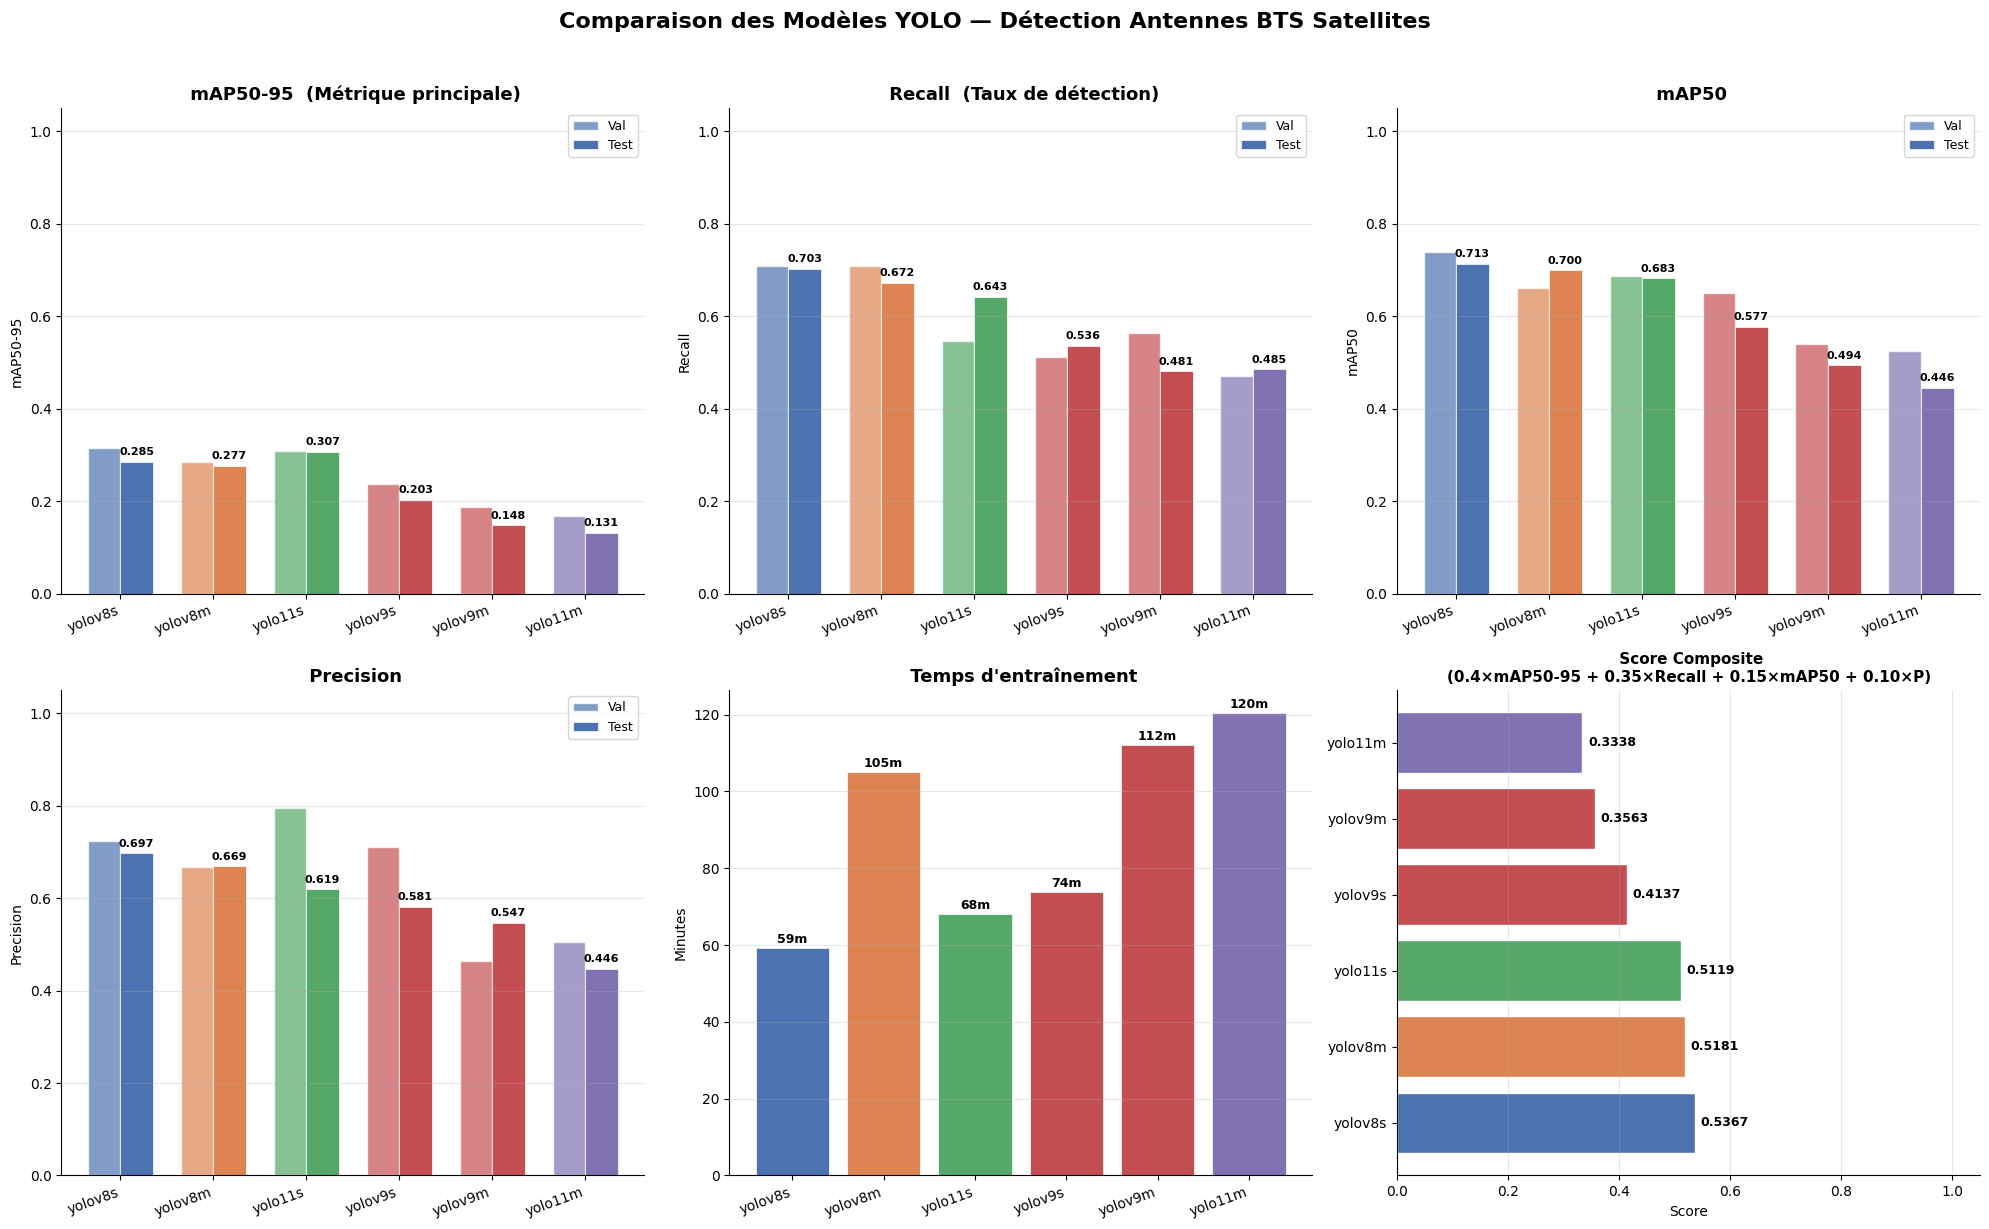


 Graphique sauvegardé → /content/drive/MyDrive/YOLO_project/results/comparaison_yolo.png


In [ ]:
# ================================================================
#  GRAPHIQUES COMPARATIFS — 4 métriques + temps + radar
# ================================================================

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#C44E52", "#8172B2"]
models = list(df_sorted.index)
x      = np.arange(len(models))
BAR_W  = 0.35

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Comparaison des Modèles YOLO — Détection Antennes BTS Satellites",
             fontsize=16, fontweight="bold", y=1.02)

# --- Helpers ---
def bar_chart(ax, metric_val, metric_test, title, ylabel, ylim=(0, 1.05)):
    b1 = ax.bar(x - BAR_W/2, metric_val,  BAR_W, label="Val",  color=COLORS, alpha=0.7, edgecolor="white")
    b2 = ax.bar(x + BAR_W/2, metric_test, BAR_W, label="Test", color=COLORS, alpha=1.0, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=10)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    # Annotations
    for bar in b2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# --- 1. mAP50-95 ---
bar_chart(axes[0,0],
    [all_results[m]["val"]["mAP50_95"]  for m in models],
    [all_results[m]["test"]["mAP50_95"] for m in models],
    " mAP50-95  (Métrique principale)", "mAP50-95")

# --- 2. Recall ---
bar_chart(axes[0,1],
    [all_results[m]["val"]["recall"]  for m in models],
    [all_results[m]["test"]["recall"] for m in models],
    " Recall  (Taux de détection)", "Recall")

# --- 3. mAP50 ---
bar_chart(axes[0,2],
    [all_results[m]["val"]["mAP50"]  for m in models],
    [all_results[m]["test"]["mAP50"] for m in models],
    " mAP50", "mAP50")

# --- 4. Precision ---
bar_chart(axes[1,0],
    [all_results[m]["val"]["precision"]  for m in models],
    [all_results[m]["test"]["precision"] for m in models],
    " Precision", "Precision")

# --- 5. Temps d'entraînement ---
ax5 = axes[1,1]
times = [all_results[m]["train_time_min"] for m in models]
bars  = ax5.bar(x, times, color=COLORS, edgecolor="white", linewidth=0.5)
ax5.set_title(" Temps d'entraînement", fontweight="bold", fontsize=13)
ax5.set_ylabel("Minutes")
ax5.set_xticks(x)
ax5.set_xticklabels(models, rotation=20, ha="right", fontsize=10)
ax5.grid(axis="y", alpha=0.3)
ax5.spines[["top", "right"]].set_visible(False)
for bar, t in zip(bars, times):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{t:.0f}m", ha="center", va="bottom", fontsize=9, fontweight="bold")

# --- 6. Score composite ---
ax6 = axes[1,2]
scores = df_sorted["Score"].values
cols_sorted = [COLORS[list(df_sorted.index).index(m)] for m in df_sorted.index]
bars2 = ax6.barh(df_sorted.index, scores, color=cols_sorted, edgecolor="white")
ax6.set_title(" Score Composite\n(0.4×mAP50-95 + 0.35×Recall + 0.15×mAP50 + 0.10×P)",
              fontweight="bold", fontsize=11)
ax6.set_xlabel("Score")
ax6.set_xlim(0, 1.05)
ax6.grid(axis="x", alpha=0.3)
ax6.spines[["top", "right"]].set_visible(False)
for bar, s in zip(bars2, scores):
    ax6.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{s:.4f}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
fig_path = f"{RESULTS_PATH}/comparaison_yolo.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n Graphique sauvegardé → {fig_path}")

##  Étape 8 — Radar Vue synthétique de tous les modèles sur toutes les métriques

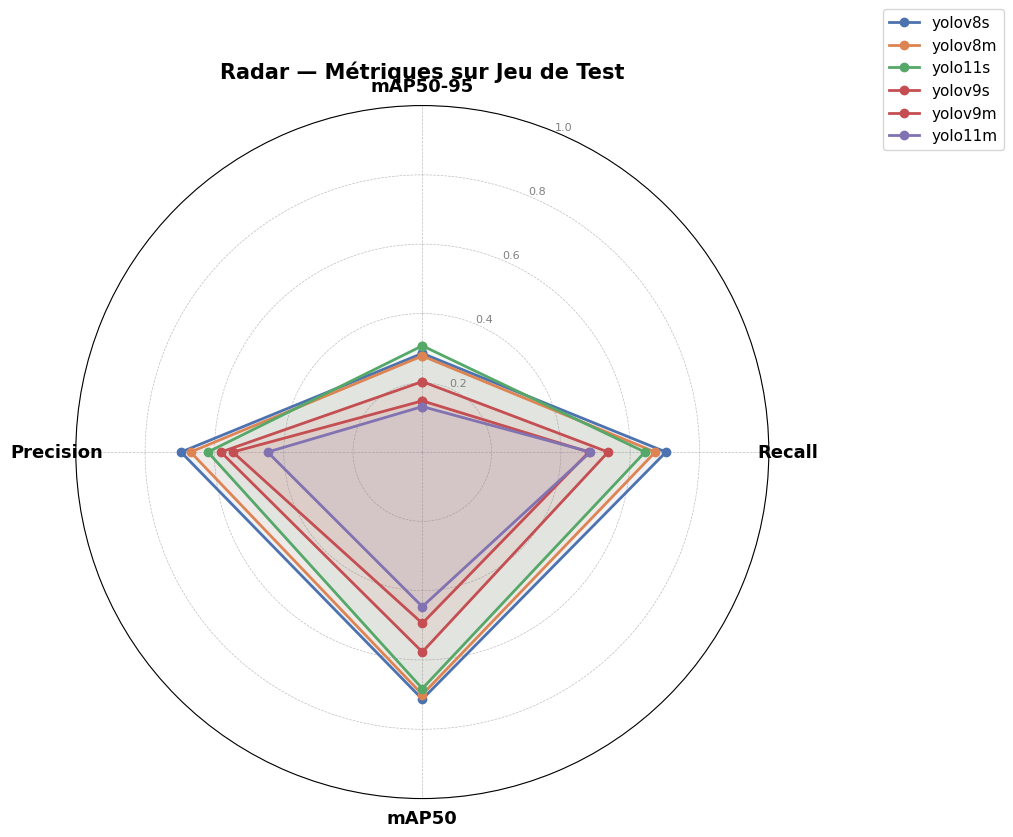


 vue synthétique de tous les modèles sur toutes les métriques → /content/drive/MyDrive/YOLO_project/results/radar_modeles.png


In [ ]:
# ================================================================
#  Radar :uue synthétique de tous les modèles sur toutes les métriques
# ================================================================

metrics_labels = ["mAP50-95", "Recall", "mAP50", "Precision"]
N = len(metrics_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for i, model in enumerate(models):
    vals = [
        all_results[model]["test"]["mAP50_95"],
        all_results[model]["test"]["recall"],
        all_results[model]["test"]["mAP50"],
        all_results[model]["test"]["precision"],
    ]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=model, color=COLORS[i])
    ax.fill(angles, vals, alpha=0.08, color=COLORS[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_labels, fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="grey")
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_title("Radar — Métriques sur Jeu de Test", fontsize=15, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)

radar_path = f"{RESULTS_PATH}/radar_modeles.png"
plt.savefig(radar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n vue synthétique de tous les modèles sur toutes les métriques → {radar_path}")

## Étape 9 — Analyse de surapprentissage (Overfitting Check)

In [ ]:
# ================================================================
#  OVERFITTING CHECK : Val vs Test mAP50-95
#  Si val >> test → surapprentissage
# ================================================================

print("\n ANALYSE OVERFITTING (Val vs Test mAP50-95)")
print("-" * 50)
for model in models:
    v = all_results[model]["val"]["mAP50_95"]
    t = all_results[model]["test"]["mAP50_95"]
    diff = v - t
    flag = " Overfitting probable" if diff > 0.05 else "Stable"
    print(f"  {model:<12} | Val: {v:.4f}  Test: {t:.4f}  Δ: {diff:+.4f}  {flag}")


 ANALYSE OVERFITTING (Val vs Test mAP50-95)
--------------------------------------------------
  yolov8s      | Val: 0.3147  Test: 0.2848  Δ: +0.0299  Stable
  yolov8m      | Val: 0.2841  Test: 0.2774  Δ: +0.0067  Stable
  yolo11s      | Val: 0.3078  Test: 0.3068  Δ: +0.0010  Stable
  yolov9s      | Val: 0.2380  Test: 0.2034  Δ: +0.0346  Stable
  yolov9m      | Val: 0.1878  Test: 0.1478  Δ: +0.0400  Stable
  yolo11m      | Val: 0.1674  Test: 0.1312  Δ: +0.0361  Stable


##  Étape 10 — Prédictions visuelles sur le meilleur modèle

In [ ]:
# ================================================================
#  PRÉDICTIONS VISUELLES — meilleur modèle sur le jeu de test
# ================================================================

best_model_name = df_sorted.index[0]
best_weights    = f"{RESULTS_PATH}/{best_model_name}_best.pt"

print(f" Meilleur modèle sélectionné : {best_model_name}")

best_model = YOLO(best_weights)
best_model.predict(
    source  = f"{DATASET_PATH}/images/test",
    save    = True,
    conf    = 0.25,
    iou     = 0.45,
    project = f"{RESULTS_PATH}/predictions",
    name    = best_model_name,
    verbose = False,
)
print(f"Prédictions sauvegardées → {RESULTS_PATH}/predictions/{best_model_name}")

 Meilleur modèle sélectionné : yolov8s
Results saved to /content/drive/MyDrive/YOLO_project/results/predictions/yolov8s2
Prédictions sauvegardées → /content/drive/MyDrive/YOLO_project/results/predictions/yolov8s
